In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import zipfile
import io
import pyarrow as pa
import sys

sys.path.append(str(Path("..").resolve()))
from config import DATA_RAW

In [ ]:
def read_zip_csv(zip_path: Path) -> pl.LazyFrame:
    """Read the CSV inside a zip into a Polars LazyFrame."""
    with zipfile.ZipFile(zip_path) as zf:
        csv_name = [f for f in zf.namelist() if f.endswith(".csv")][0]
        with zf.open(csv_name) as f:
            raw = f.read()
    return pl.read_csv(
        io.BytesIO(raw),
        infer_schema_length=1000,
        null_values=["", "NA", "null", "NULL"],
    )


df = read_zip_csv(Path(DATA_RAW / "aisdk-2025-06-01.zip"))
df = df.filter(pl.col("Ship type").is_in(["Cargo", "Tanker", "Fishing", "Tug", "Passenger"]))

In [3]:
df[:10]

# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,IMO,Callsign,Name,Ship type,Cargo type,Width,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
str,str,i64,f64,f64,str,f64,f64,f64,i64,str,str,str,str,str,i64,i64,str,f64,str,str,str,i64,i64,i64,i64
"""01/06/2025 00:00:00""","""Class A""",211452000,91.0,0.0,"""Unknown value""",null,null,null,null,"""Unknown""","""DNPO""","""SH10 FRIGGA""","""Fishing""",null,6,23,"""GPS""",2.8,"""A'MONRA""",null,"""AIS""",20,3,3,3
"""01/06/2025 00:00:00""","""Class A""",211452000,91.0,0.0,"""Unknown value""",null,null,null,null,"""Unknown""","""DNPO""","""SH10 FRIGGA""","""Fishing""",null,6,23,"""GPS""",2.8,"""A'MONRA""",null,"""AIS""",20,3,3,3
"""01/06/2025 00:00:00""","""Class A""",265572330,91.0,0.0,"""Unknown value""",null,null,null,null,"""5305302""","""SIEK""","""FALKSKAR II""","""Passenger""",null,7,27,"""Internal""",2.8,"""SELKA. .""","""20/05/2026 21:30:00""","""AIS""",11,16,3,4
"""01/06/2025 00:00:00""","""Class A""",246389000,91.0,0.0,"""Unknown value""",null,null,null,null,"""8433265""","""PDHJ""","""BRANDARIS""","""Tug""",null,5,15,"""GPS""",2.2,"""VORDINGBORG""","""31/05/2026 19:00:00""","""AIS""",5,10,2,3
"""01/06/2025 00:00:00""","""Class B""",219005662,55.512945,9.629945,"""Unknown value""",null,0.0,305.9,305,"""Unknown""","""Unknown""","""LILLE BO""","""Fishing""",null,4,11,"""GPS""",null,"""Unknown""",null,"""AIS""",3,8,2,2
"""01/06/2025 00:00:01""","""Class B""",219006164,91.0,0.0,"""Unknown value""",null,null,null,null,"""Unknown""","""XP4037""","""E BOSSEN HG220""","""Fishing""",null,3,8,"""Undefined""",null,"""Unknown""",null,"""AIS""",6,2,2,1
"""01/06/2025 00:00:01""","""Class A""",257084120,91.0,0.0,"""Unknown value""",null,null,null,null,"""9829796""","""LAGK6""","""VIKSTRAUM""","""Tanker""","""Category Y""",20,129,"""GPS""",8.3,"""LTKLJ""","""02/06/2025 15:00:00""","""AIS""",105,24,3,17
"""01/06/2025 00:00:01""","""Class A""",257084120,91.0,0.0,"""Unknown value""",null,null,null,null,"""9829796""","""LAGK6""","""VIKSTRAUM""","""Tanker""","""Category Y""",20,129,"""GPS""",8.3,"""LTKLJ""","""02/06/2025 15:00:00""","""AIS""",105,24,3,17
"""01/06/2025 00:00:01""","""Class A""",247312900,54.776417,12.420117,"""Under way using engine""",0.0,8.8,216.3,211,"""9490052""","""ICSJ""","""AIDAMAR""","""Passenger""",null,38,253,"""GPS""",7.3,"""DE RSK""","""01/06/2025 04:15:00""","""AIS""",46,207,19,19


shape: (1_304, 2)
┌─────────┬───────────┐
│ IMO     ┆ row_count │
│ ---     ┆ ---       │
│ str     ┆ u32       │
╞═════════╪═══════════╡
│ Unknown ┆ 3518762   │
│ 9941518 ┆ 53520     │
│ 6720004 ┆ 51421     │
│ 9908138 ┆ 44859     │
│ 9498341 ┆ 44512     │
│ …       ┆ …         │
│ 9545039 ┆ 1         │
│ 8026361 ┆ 1         │
│ 9811581 ┆ 1         │
│ 9239616 ┆ 1         │
│ 7525918 ┆ 1         │
└─────────┴───────────┘


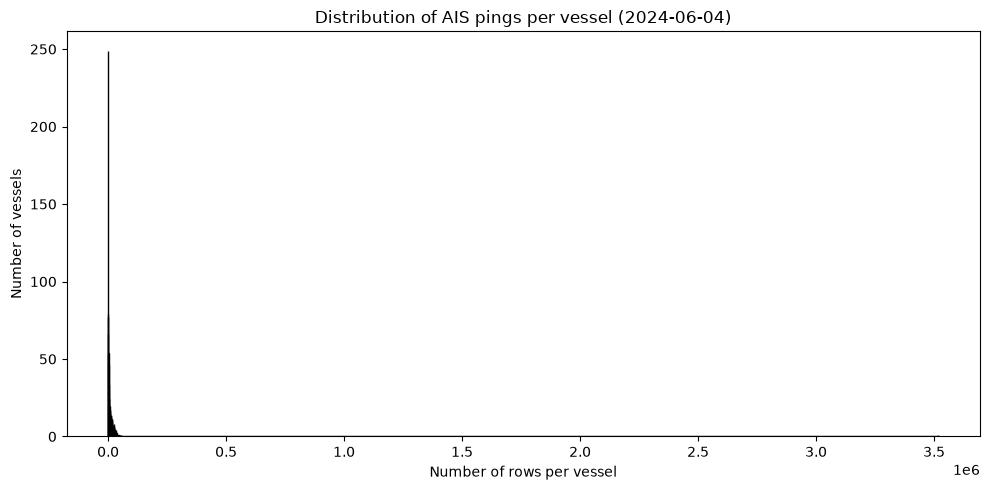

In [ ]:
# get count of rows per vessel
vessel_counts = df.group_by(["IMO"]).agg(pl.len().alias("row_count")).sort("row_count", descending=True)

print(vessel_counts)

plt.figure(figsize=(10, 5))
plt.hist(vessel_counts["row_count"].to_numpy(), bins=10000, edgecolor="black")
plt.xlabel("Number of rows per vessel")
plt.ylabel("Number of vessels")
plt.title("Distribution of AIS pings per vessel (2024-06-04)")
plt.tight_layout()
plt.show()

In [ ]:
# get count of rows per ship type
vessel_counts_st = df.group_by(["Ship type"]).agg(pl.len().alias("row_count")).sort("row_count", descending=True)

print(vessel_counts_st)

shape: (5, 2)
┌───────────┬───────────┐
│ Ship type ┆ row_count │
│ ---       ┆ ---       │
│ str       ┆ u32       │
╞═══════════╪═══════════╡
│ Cargo     ┆ 4236375   │
│ Fishing   ┆ 3747052   │
│ Passenger ┆ 2421880   │
│ Tanker    ┆ 2010873   │
│ Tug       ┆ 636290    │
└───────────┴───────────┘


In [6]:
size = len(df)
print(f"""Dataset size: {size} rows \n
    Number of vessels in dataset: {len(df["IMO"].unique())}\n
    Max rows for a single vessel: {vessel_counts[0, "row_count"]}\n
    Median rows per vessel: {vessel_counts["row_count"].median()}\n
    Mean rows per vessel: {vessel_counts["row_count"].mean()}\n
    number of vessels with more than {60 * 24} rows: {(vessel_counts["row_count"] > 60 * 24).sum()}\n
    number of vessels with under {24 * 6} row: {(vessel_counts["row_count"] < 24 * 6).sum()}""")

Dataset size: 13052470 rows 

    Number of vessels in dataset: 1304

    Max rows for a single vessel: 3518762

    Median rows per vessel: 3273.5

    Mean rows per vessel: 10009.562883435583

    number of vessels with more than 1440 rows: 828

    number of vessels with under 144 row: 165


In [ ]:
## percentage of null values per column
for col in df.columns:
    n = len(df)
    null_count = df[col].is_null().sum() / n * 100
    unknown_count = ((df[col].cast(pl.Utf8) == "Unknown").sum() + (df[col].cast(pl.Utf8) == "Unknown value").sum()) / n * 100
    undefined_count = (df[col].cast(pl.Utf8) == "Undefined").sum() / n * 100
    total_pct = null_count + unknown_count + undefined_count
    print(f"\n{col}: \n{null_count:.2f}% null, \n{unknown_count:.2f}% unknown, \n{undefined_count:.2f}% undefined, \n{total_pct:.2f}% total missing/unknown/undefined")


# Timestamp: 
0.00% null, 
0.00% unknown, 
0.00% undefined, 
0.00% total missing/unknown/undefined

Type of mobile: 
0.00% null, 
0.00% unknown, 
0.00% undefined, 
0.00% total missing/unknown/undefined

MMSI: 
0.00% null, 
0.00% unknown, 
0.00% undefined, 
0.00% total missing/unknown/undefined

Latitude: 
0.00% null, 
0.00% unknown, 
0.00% undefined, 
0.00% total missing/unknown/undefined

Longitude: 
0.00% null, 
0.00% unknown, 
0.00% undefined, 
0.00% total missing/unknown/undefined

Navigational status: 
0.00% null, 
5.60% unknown, 
0.00% undefined, 
5.60% total missing/unknown/undefined

ROT: 
15.47% null, 
0.00% unknown, 
0.00% undefined, 
15.47% total missing/unknown/undefined

SOG: 
0.17% null, 
0.00% unknown, 
0.00% undefined, 
0.17% total missing/unknown/undefined

COG: 
4.43% null, 
0.00% unknown, 
0.00% undefined, 
4.43% total missing/unknown/undefined

Heading: 
8.25% null, 
0.00% unknown, 
0.00% undefined, 
8.25% total missing/unknown/undefined

IMO: 
0.00% null, 
26.96% 

In [8]:
count = df["IMO"].value_counts()
print(count)

shape: (1_304, 2)
┌─────────┬───────┐
│ IMO     ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ 9107136 ┆ 13432 │
│ 9021124 ┆ 17444 │
│ 8513314 ┆ 32    │
│ 9781865 ┆ 22875 │
│ 9364136 ┆ 193   │
│ …       ┆ …     │
│ 9521356 ┆ 2979  │
│ 8892241 ┆ 912   │
│ 9101144 ┆ 5472  │
│ 9709128 ┆ 219   │
│ 9344435 ┆ 4805  │
└─────────┴───────┘


In [9]:
count = df["Navigational status"].value_counts().sort("count", descending=True)

for status, cnt in zip(count["Navigational status"], count["count"]):
    print(f"{status}: {cnt}")


Under way using engine: 8911125
Engaged in fishing: 2254455
Unknown value: 730289
Constrained by her draught: 324133
Moored: 301012
Restricted maneuverability: 179685
Under way sailing: 125703
At anchor: 104067
Power-driven vessel towing astern: 47457
Power-driven vessel pushing ahead or towing alongside: 26690
Not under command: 21901
Reserved for future amendment [HSC]: 12567
Reserved for future use: 11749
Aground: 1635
Reserved for future amendment [WIG]: 2


In [10]:
count = df["Cargo type"].value_counts().sort("count", descending=True)

for status, cnt in zip(count["Cargo type"], count["count"]):
    print(f"{status}: {cnt}")


None: 10137724
No additional information: 1868765
Category X: 406465
Category OS: 271210
Reserved for future use: 176133
Category Y: 162170
Category Z: 30003
